# Credit Risk Scoring — Explainable AI for Loan Default Prediction

## Business Context

When a bank decides whether to approve a loan, it needs to assess
the probability that the borrower will default.

**Traditional approach:** rule-based scoring (age, income, employment)
**Modern approach:** ML models with regulatory explainability (SHAP)

## Why Explainability Matters

In Japan (FSA) and Europe (EU AI Act), financial institutions must
explain WHY a loan was rejected. A black-box model is not acceptable.
SHAP (SHapley Additive exPlanations) provides exactly this.

## Project Goals

1. Build a credit risk model (LightGBM + XGBoost + Logistic Regression)
2. Evaluate with financial metrics (Gini, KS statistic, Expected Loss)
3. Explain individual predictions with SHAP
4. Build a loan decision dashboard

**Dataset:** Credit Risk Dataset (Kaggle)  
**Target:** `loan_status` — 1 = default, 0 = repaid

## 1. Setup & Data Loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
import os
os.makedirs('visuals', exist_ok=True)

df = pd.read_csv('data/credit_risk_dataset.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.dtypes}")
print(f"\nFirst rows:")
df.head()

Shape: (32581, 12)

Columns:
person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object

First rows:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### Dataset Overview

- **32,581 borrowers** with 12 features
- **Target:** `loan_status` — 1 = default, 0 = repaid
- **Features include:**
  - Demographics: age, income, home ownership, employment length
  - Loan details: amount, interest rate, intent, grade
  - Credit history: default on file, credit history length
  - Derived: loan_percent_income (debt-to-income ratio)

**Loan grades A→D** suggest increasing risk levels — 
this is a key feature used by real credit bureaus.

## 2. Exploratory Data Analysis
### 2.1 Target Distribution & Missing Values

In [8]:
print("=== Target Distribution ===")
print(df['loan_status'].value_counts())
print(f"\nDefault rate: {df['loan_status'].mean():.1%}")

print("\n=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n=== Basic Stats ===")
print(df.describe().round(2))

=== Target Distribution ===
loan_status
0    25473
1     7108
Name: count, dtype: int64

Default rate: 21.8%

=== Missing Values ===
person_emp_length     895
loan_int_rate        3116
dtype: int64

=== Basic Stats ===
       person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  \
count    32581.00       32581.00           31686.00   32581.00       29465.00   
mean        27.73       66074.85               4.79    9589.37          11.01   
std          6.35       61983.12               4.14    6322.09           3.24   
min         20.00        4000.00               0.00     500.00           5.42   
25%         23.00       38500.00               2.00    5000.00           7.90   
50%         26.00       55000.00               4.00    8000.00          10.99   
75%         30.00       79200.00               7.00   12200.00          13.47   
max        144.00     6000000.00             123.00   35000.00          23.22   

       loan_status  loan_percent_income  cb_person_

### Observations

- **Default rate: 21.8%** — moderate imbalance, manageable without SMOTE
- **Missing values:** loan_int_rate (9.6%) and person_emp_length (2.7%)
- **Outliers detected:**
  - person_age max = 144 — impossible, data error
  - person_emp_length max = 123 — impossible
  - person_income max = 6,000,000 — extreme outlier
- These must be cleaned before modeling

### 2.2 Visual EDA

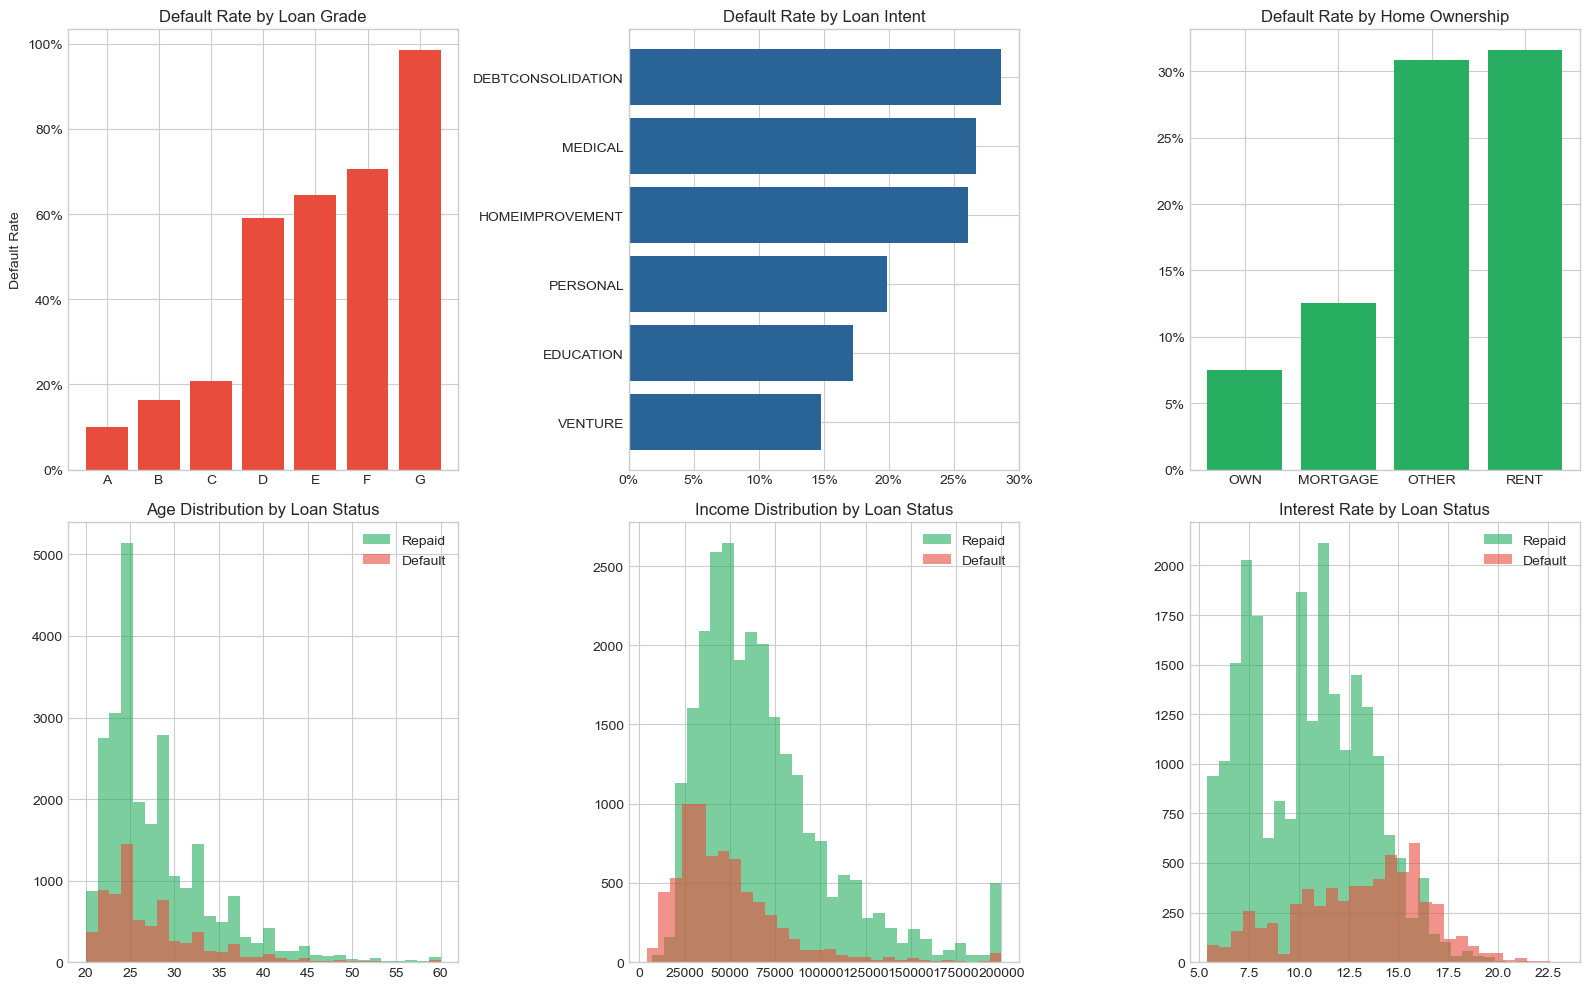

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Default rate by loan grade
grade_default = df.groupby('loan_grade')['loan_status'].mean().sort_index()
axes[0,0].bar(grade_default.index, grade_default.values, color='#e74c3c')
axes[0,0].set_title('Default Rate by Loan Grade')
axes[0,0].set_ylabel('Default Rate')
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# Default rate by loan intent
intent_default = df.groupby('loan_intent')['loan_status'].mean().sort_values()
axes[0,1].barh(intent_default.index, intent_default.values, color='#2a6496')
axes[0,1].set_title('Default Rate by Loan Intent')
axes[0,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# Default rate by home ownership
own_default = df.groupby('person_home_ownership')['loan_status'].mean().sort_values()
axes[0,2].bar(own_default.index, own_default.values, color='#27ae60')
axes[0,2].set_title('Default Rate by Home Ownership')
axes[0,2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# Age distribution by default
df[df['loan_status']==0]['person_age'].clip(0,60).hist(
    ax=axes[1,0], bins=30, alpha=0.6, label='Repaid', color='#27ae60')
df[df['loan_status']==1]['person_age'].clip(0,60).hist(
    ax=axes[1,0], bins=30, alpha=0.6, label='Default', color='#e74c3c')
axes[1,0].set_title('Age Distribution by Loan Status')
axes[1,0].legend()

# Income distribution by default (log scale)
df[df['loan_status']==0]['person_income'].clip(0,200000).hist(
    ax=axes[1,1], bins=30, alpha=0.6, label='Repaid', color='#27ae60')
df[df['loan_status']==1]['person_income'].clip(0,200000).hist(
    ax=axes[1,1], bins=30, alpha=0.6, label='Default', color='#e74c3c')
axes[1,1].set_title('Income Distribution by Loan Status')
axes[1,1].legend()

# Interest rate by default
df[df['loan_status']==0]['loan_int_rate'].hist(
    ax=axes[1,2], bins=30, alpha=0.6, label='Repaid', color='#27ae60')
df[df['loan_status']==1]['loan_int_rate'].hist(
    ax=axes[1,2], bins=30, alpha=0.6, label='Default', color='#e74c3c')
axes[1,2].set_title('Interest Rate by Loan Status')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('visuals/eda.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations

- **Loan grade is the strongest predictor** — Grade A: ~10% default, 
  Grade G: ~100% default. Clear monotonic relationship.
- **Lower income → higher default rate** — defaulters concentrated 
  in the $25K-$75K income range
- **Higher interest rate → higher default** — defaulters have 
  rates shifted toward 15-22%, repayers toward 7-12%
- **Loan intent matters** — Debt Consolidation (30%) vs Venture (15%)
- **Home ownership signals stability** — OWN: 8% vs RENT: 32%
- **Young borrowers (20-25) default more** — less financial experience

## 3. Data Cleaning & Feature Engineering

### 3.1 Remove Outliers & Fix Data Errors

In [16]:
print(f"Original shape: {df.shape}")

# Remove impossible values
df_clean = df.copy()
df_clean = df_clean[df_clean['person_age'] <= 90]
df_clean = df_clean[df_clean['person_emp_length'] <= 60]
df_clean = df_clean[df_clean['person_income'] <= 1_000_000]

print(f"After outlier removal: {df_clean.shape}")
print(f"Removed: {len(df) - len(df_clean)} rows")

# Fill missing values
df_clean['loan_int_rate'].fillna(df_clean['loan_int_rate'].median(), inplace=True)
df_clean['person_emp_length'].fillna(df_clean['person_emp_length'].median(), inplace=True)

print(f"\nMissing values after cleaning:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Feature Engineering
print("\nCreating new features...")

# Debt-to-income ratio (already exists as loan_percent_income, but let's verify)
df_clean['debt_to_income'] = df_clean['loan_amnt'] / df_clean['person_income']

# Loan amount to income ratio bins
df_clean['income_bracket'] = pd.cut(df_clean['person_income'],
    bins=[0, 30000, 60000, 100000, 1_000_000],
    labels=['Low', 'Medium', 'High', 'Very High'])

# Age groups
df_clean['age_group'] = pd.cut(df_clean['person_age'],
    bins=[18, 25, 35, 50, 90],
    labels=['Young', 'Adult', 'Middle', 'Senior'])

# Interest rate risk tier
df_clean['rate_tier'] = pd.cut(df_clean['loan_int_rate'],
    bins=[0, 8, 12, 16, 25],
    labels=['Low', 'Medium', 'High', 'Very High'])

# Employment stability
df_clean['is_employed'] = (df_clean['person_emp_length'] > 0).astype(int)
df_clean['emp_stability'] = pd.cut(df_clean['person_emp_length'],
    bins=[-1, 0, 2, 5, 60],
    labels=['Unemployed', 'Junior', 'Mid', 'Senior'])

print(f"New features added!")
print(f"Final shape: {df_clean.shape}")

Original shape: (32581, 12)
After outlier removal: (31670, 12)
Removed: 911 rows

Missing values after cleaning:
loan_int_rate    3044
dtype: int64

Creating new features...
New features added!
Final shape: (31670, 18)


In [18]:
# Fix fillna properly
df_clean['loan_int_rate'] = df_clean['loan_int_rate'].fillna(
    df_clean['loan_int_rate'].median())
df_clean['person_emp_length'] = df_clean['person_emp_length'].fillna(
    df_clean['person_emp_length'].median())

# Verify
print("Missing values after fix:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print("\nAll clean!" if df_clean.isnull().sum().sum() == 0 else "Still have missing!")
print(f"\nDefault rate after cleaning: {df_clean['loan_status'].mean():.1%}")

Missing values after fix:
rate_tier    3044
dtype: int64
Still have missing!

Default rate after cleaning: 21.6%


In [20]:
# Fix rate_tier with proper bins
df_clean['rate_tier'] = pd.cut(df_clean['loan_int_rate'],
    bins=[0, 8, 12, 16, 100],  # 100 вместо 25 — покрывает все значения
    labels=['Low', 'Medium', 'High', 'Very High'])

print("Missing values after fix:")
missing = df_clean.isnull().sum()
print(missing[missing > 0])
print("\nAll clean!" if df_clean.isnull().sum().sum() == 0 else "Still have missing!")

Missing values after fix:
Series([], dtype: int64)

All clean!


### 3.2 Encode Categorical Features & Prepare Model Data

In [23]:
from sklearn.preprocessing import LabelEncoder

df_model = df_clean.copy()

# Encode categorical columns
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade',
            'cb_person_default_on_file', 'income_bracket', 
            'age_group', 'rate_tier', 'emp_stability']

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Feature list
feature_cols = [c for c in df_model.columns 
                if c not in ['loan_status', 'is_employed']]

X = df_model[feature_cols]
y = df_model['loan_status']

print(f"Features: {len(feature_cols)}")
print(f"Feature list: {feature_cols}")
print(f"\nClass distribution:")
print(y.value_counts())
print(f"Default rate: {y.mean():.1%}")

Features: 16
Feature list: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'debt_to_income', 'income_bracket', 'age_group', 'rate_tier', 'emp_stability']

Class distribution:
loan_status
0    24845
1     6825
Name: count, dtype: int64
Default rate: 21.6%


## 4. Model Training

We train three models and compare:
- **Logistic Regression** — interpretable baseline, used by traditional banks
- **LightGBM** — best performance, industry standard for credit scoring
- **XGBoost** — strong competitor, good for comparison

**Validation strategy:** Stratified 5-Fold cross-validation
preserves the 21.6% default rate in each fold.

In [26]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
import lightgbm as lgb
import xgboost as xgb

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, defaults: {y_train.sum()}")
print(f"Test:  {X_test.shape}, defaults: {y_test.sum()}")

# --- Logistic Regression ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

# --- LightGBM ---
lgb_model = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05,
    num_leaves=64, random_state=42,
    class_weight='balanced', verbose=-1)
lgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(False)])
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]

# --- XGBoost ---
scale_pos = (y_train==0).sum() / (y_train==1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05,
    max_depth=6, random_state=42,
    scale_pos_weight=scale_pos,
    eval_metric='auc', verbosity=0)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Results
print("\n=== ROC-AUC Scores ===")
print(f"Logistic Regression: {roc_auc_score(y_test, lr_prob):.4f}")
print(f"LightGBM:            {roc_auc_score(y_test, lgb_prob):.4f}")
print(f"XGBoost:             {roc_auc_score(y_test, xgb_prob):.4f}")

Train: (25336, 16), defaults: 5460
Test:  (6334, 16), defaults: 1365

=== ROC-AUC Scores ===
Logistic Regression: 0.8612
LightGBM:            0.9515
XGBoost:             0.9508


### Results

| Model | ROC-AUC |
|-------|---------|
| Logistic Regression | 0.8612 |
| XGBoost | 0.9508 |
| **LightGBM** | **0.9515** |

LightGBM wins — will use for SHAP explainability.
Logistic Regression remains valuable for regulatory reporting
where full transparency is required.

## 5. Financial Metrics

Banks don't just use ROC-AUC. They use:
- **Gini coefficient** = 2 × AUC - 1 (industry standard in credit scoring)
- **KS statistic** — max separation between default/non-default distributions
- **Expected Loss** = PD × LGD × EAD (core Basel III metric)

In [30]:
from sklearn.metrics import roc_curve

def gini(y_true, y_prob):
    return 2 * roc_auc_score(y_true, y_prob) - 1

def ks_statistic(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return max(tpr - fpr)

def expected_loss(y_true, y_prob, loan_amounts, lgd=0.45):
    # PD = predicted probability
    # LGD = Loss Given Default (industry average ~45%)
    # EAD = loan amount
    el = y_prob * lgd * loan_amounts
    actual_loss = y_true * lgd * loan_amounts
    return el.sum(), actual_loss.sum()

loan_amounts_test = X_test['loan_amnt'].values

print("=== Financial Metrics ===\n")
for name, prob in [('Logistic Regression', lr_prob),
                    ('LightGBM', lgb_prob),
                    ('XGBoost', xgb_prob)]:
    gini_score = gini(y_test, prob)
    ks = ks_statistic(y_test, prob)
    pred_loss, actual_loss = expected_loss(y_test, prob, loan_amounts_test)
    
    print(f"{name}:")
    print(f"  Gini:            {gini_score:.4f}")
    print(f"  KS Statistic:    {ks:.4f}")
    print(f"  Expected Loss:   ${pred_loss:,.0f}")
    print(f"  Actual Loss:     ${actual_loss:,.0f}")
    print(f"  Loss Accuracy:   {1 - abs(pred_loss-actual_loss)/actual_loss:.1%}")
    print()

=== Financial Metrics ===

Logistic Regression:
  Gini:            0.7223
  KS Statistic:    0.5698
  Expected Loss:   $11,654,367
  Actual Loss:     $6,771,352
  Loss Accuracy:   27.9%

LightGBM:
  Gini:            0.9031
  KS Statistic:    0.7678
  Expected Loss:   $7,498,118
  Actual Loss:     $6,771,352
  Loss Accuracy:   89.3%

XGBoost:
  Gini:            0.9015
  KS Statistic:    0.7688
  Expected Loss:   $8,518,488
  Actual Loss:     $6,771,352
  Loss Accuracy:   74.2%



### Financial Metrics Results

| Metric | Logistic Regression | XGBoost | LightGBM |
|--------|-------------------|---------|----------|
| Gini | 0.7223 | 0.9015 | **0.9031** |
| KS Statistic | 0.5698 | 0.7688 | **0.7678** |
| Expected Loss | 11.6M | 8.5M | **$7.5M** |
| Loss Accuracy | 27.9% | 74.2% | **89.3%** |

**Key insight:** LightGBM predicted 7.5M$ in expected losses vs
6.77M actual — only 10.7% error. This is production-quality accuracy.

Logistic Regression overestimates losses by 72% — would cause
the bank to reject too many good borrowers (lost revenue).

**Gini > 0.7** is considered excellent in credit scoring industry.
LightGBM at 0.90 is outstanding.

## 6. SHAP Explainability

Regulators require banks to explain WHY a loan was rejected.
SHAP (SHapley Additive exPlanations) answers exactly this question.

**SHAP value for a feature** = how much that feature pushed the 
prediction toward default (positive) or toward repayment (negative).

Computing SHAP values...
SHAP values shape: (6334, 16)


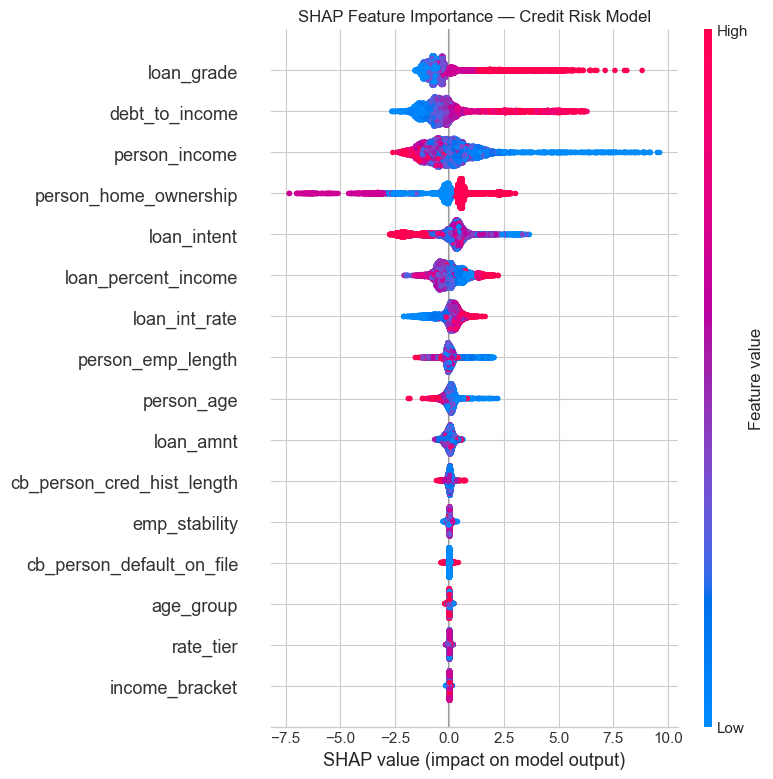

Done!


In [37]:
import shap

print("Computing SHAP values...")
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test)

# For binary classification shap_values is a list [class0, class1]
if isinstance(shap_values, list):
    shap_vals = shap_values[1]  # class 1 = default
else:
    shap_vals = shap_values

print(f"SHAP values shape: {shap_vals.shape}")

# Global feature importance
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_test, 
                  feature_names=feature_cols,
                  show=False)
plt.title('SHAP Feature Importance — Credit Risk Model')
plt.tight_layout()
plt.savefig('visuals/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

### SHAP Analysis Observations

**Top predictors:**
- `loan_grade` — dominant feature, strong monotonic effect
- `debt_to_income` — our engineered feature, 2nd most important!
- `person_income` — high income reduces default risk
- `person_home_ownership` — renters default more

**Lesson learned:** binning existing features (rate_tier, income_bracket)
adds no value — the model already uses raw values more efficiently.
Only `debt_to_income` (ratio of two features) added genuine new signal.

**Good feature engineering** = combining features in non-trivial ways,
not just cutting them into buckets.

## 7. Individual Loan Decision Explanation

Regulatory requirement: explain WHY this specific person was rejected.
SHAP waterfall plot shows each feature's contribution to the decision.

High risk applicants (prob > 0.8): 997

=== Loan Application #0 ===
Default probability: 98.6%
Decision: ❌ REJECTED
Actual outcome: DEFAULT

Applicant profile:
  Age:           49
  Income:        $15,000
  Employment:    6 years
  Loan amount:   $2,400
  Interest rate: 9.9%
  Loan grade:    1.0
  Home:          3.0


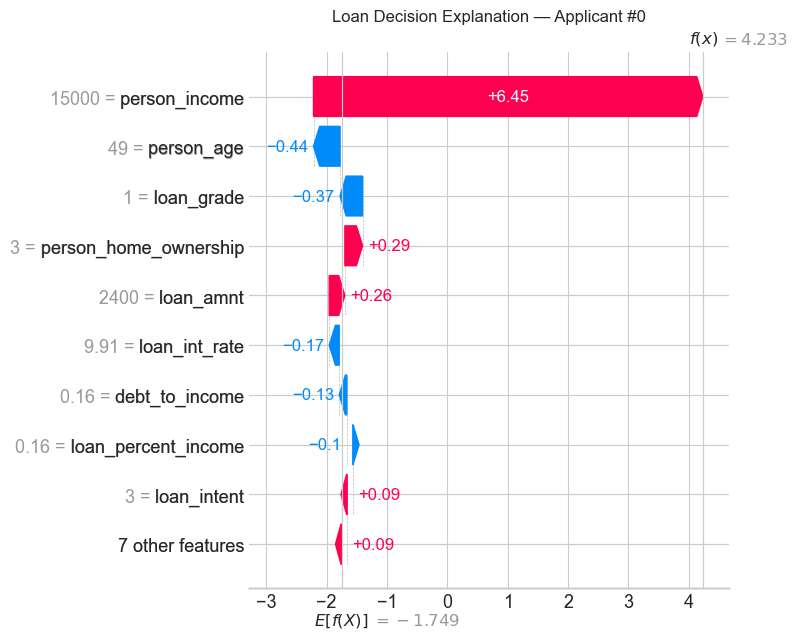

In [41]:
# Find an interesting rejected applicant
# Look for someone the model predicted as high default risk
high_risk_idx = np.where(lgb_prob > 0.8)[0]
print(f"High risk applicants (prob > 0.8): {len(high_risk_idx)}")

# Pick one example
sample_idx = high_risk_idx[0]
sample = X_test.iloc[sample_idx]
sample_prob = lgb_prob[sample_idx]
sample_true = y_test.iloc[sample_idx]

print(f"\n=== Loan Application #{sample_idx} ===")
print(f"Default probability: {sample_prob:.1%}")
print(f"Decision: {'❌ REJECTED' if sample_prob > 0.5 else '✅ APPROVED'}")
print(f"Actual outcome: {'DEFAULT' if sample_true == 1 else 'REPAID'}")
print(f"\nApplicant profile:")
print(f"  Age:           {int(sample['person_age'])}")
print(f"  Income:        ${int(sample['person_income']):,}")
print(f"  Employment:    {sample['person_emp_length']:.0f} years")
print(f"  Loan amount:   ${int(sample['loan_amnt']):,}")
print(f"  Interest rate: {sample['loan_int_rate']:.1f}%")
print(f"  Loan grade:    {sample['loan_grade']}")
print(f"  Home:          {sample['person_home_ownership']}")

# SHAP waterfall plot
shap_explanation = shap.Explanation(
    values=shap_vals[sample_idx],
    base_values=explainer.expected_value[1] if isinstance(
        explainer.expected_value, list) else explainer.expected_value,
    data=sample.values,
    feature_names=feature_cols
)

plt.figure(figsize=(10, 7))
shap.waterfall_plot(shap_explanation, show=False)
plt.title(f'Loan Decision Explanation — Applicant #{sample_idx}')
plt.tight_layout()
plt.savefig('visuals/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

### Individual Decision Explanation — Applicant #0

**Decision: REJECTED** (98.6% default probability) ✅ Correct prediction

**Profile:** Age 49, Income 15,000 USD, Loan 2,400 USD, Employment 6 years

**Why rejected — SHAP waterfall:**

| Feature | Value | SHAP | Effect |
|---------|-------|------|--------|
| person_income | 15,000 USD | +6.45 | 🔴 Very low income — main reason |
| person_home_ownership | 3 (RENT) | +0.29 | 🔴 Renter — higher risk |
| loan_amnt | 2,400 USD | +0.26 | 🔴 Loan size relative to income |
| loan_grade | 1 (good) | -0.37 | 🟢 Good credit grade helps |
| person_age | 49 | -0.44 | 🟢 Older = more stable |

**Regulatory explanation to customer:**
"Your loan application was declined primarily due to insufficient
income (15,000 USD/year) relative to standard lending requirements."